# Figure 8 — Deterministic reward contingencies reorganize behavioral strategy through state-specific changes in reward sensitivity

Manuscript Fig 8 legend (~page 29 of `2026.06.30.734629v1.full (4).pdf`).

**FULL REBUILD** on the manuscript's canonical 7-state taxonomy
(`state_classifier.classify_state_v7`), replacing the earlier build's
`classify_state_updated`-based `Figure_8f`/`Figure_8fg`-only scope (that build's
own outputs and Left/Right-Bias-only framing are superseded by the panels below,
not kept alongside them). 100-0 data reconstruction
(`src/behavior_metrics/cross_condition.py::build_100_0_features_df`,
`create_correct_pseudo_sessions`) is unchanged and reused as-is -- only the
classifier and the downstream panels have changed. Standing constraint: no
threshold here is tuned to match the manuscript's printed numbers.

In [1]:
import os
import sys
import json
import functools

import numpy as np
import pandas as pd

sys.path.insert(0, os.path.abspath(".."))

from src.io.load_snapshots import load_config, load_snapshot
from src.features import state_features
from src.behavior_metrics import (
    state_classifier, cross_condition, state_taxonomy_v7 as sx7,
    reversal_alignment as ra, q_following_model,
)
from src.plotting.style import apply_style
from src.plotting import fig8 as plotting

config = load_config()
apply_style(config)
cfg = config["fig8"]
st_cfg = config["state_taxonomy"]
OVERLAPPING_ANIMALS = cfg["overlapping_animals"]

FIG_DIR = os.path.join("..", config["paths"]["figures_out"], "Fig8")
os.makedirs(FIG_DIR, exist_ok=True)
MANIFEST_DIR = os.path.join("..", config["paths"]["values_manifests_out"])
os.makedirs(MANIFEST_DIR, exist_ok=True)

manifest = {"_stage": "Fig 8 REBUILD -- 80-20 vs. 100-0, classify_state_v7"}

## 80-20 side
Reuses the already-reconstructed 80-20 state-features dataframe
(`state_features.build_state_features_df`, same one Fig 6/Fig 7/Supp Fig 4 use),
filtered to the 5 animals who ran both conditions, then classified with the new
canonical 7-state taxonomy `classify_state_v7` (fast/slow Adaptation pre-pass +
Directed/Random Exploration + Left/Right Bias + Exploit -- see
`state_classifier.py`).

In [2]:
df_80_raw = load_snapshot(config, cfg["input_files"]["reversal_80_20_2abt"])
df_80_full = state_features.build_state_features_df(
    df_80_raw, st_cfg["task_type"], st_cfg["prob_condition"], cfg["rolling_window"]
)
df_80 = df_80_full[df_80_full["Animal_Name"].isin(OVERLAPPING_ANIMALS)].copy()

block_labels_80 = state_classifier.label_block_adaptation_speed(
    df_80, st_cfg["adaptation_window"], st_cfg["adaptation_fast_accuracy_threshold"]
)
adaptation_labels_80 = state_classifier.compute_adaptation_labels(
    df_80, st_cfg["adaptation_window"], st_cfg["adaptation_fast_accuracy_threshold"],
    block_labels=block_labels_80,
)
classify_v7 = functools.partial(
    state_classifier.classify_state_v7, adaptation_labels=adaptation_labels_80, config=st_cfg["classify_updated"]
)
df_80["Behavioral_State"] = df_80.apply(classify_v7, axis=1)

print(f"80-20: {len(df_80):,} trials, {df_80['Session_ID'].nunique()} sessions, "
      f"{df_80['Animal_Name'].nunique()} animals, {len(block_labels_80)} block transitions")
manifest["n_trials_80_20"] = int(len(df_80))
manifest["n_sessions_80_20"] = int(df_80["Session_ID"].nunique())

/Users/kevinmastro/Documents/Github/marmoset_decision_making/Final_Paper_Pipeline/src/features/state_features.py:91: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  session_sides = df_filtered.groupby("Session_ID").apply(


80-20: 36,673 trials, 100 sessions, 5 animals, 1779 block transitions


## 100-0 side
Reconstructed from scratch by `cross_condition.build_100_0_features_df` (unchanged
from the prior build -- see that module's docstring for the pseudo-session-splitting
logic used), then classified with the SAME `classify_state_v7` (its fast/slow
pre-pass and block-transition machinery need only `Session_ID`/`BlockCount`/
`Block_Transition`/`Trials_Since_Transition`/`High_Prob`, all of which
`build_100_0_features_df` already provides).

In [3]:
df_100_raw = load_snapshot(config, cfg["input_files"]["reversal_100_0_raw"])
df_100 = cross_condition.build_100_0_features_df(
    df_100_raw, OVERLAPPING_ANIMALS, set(cfg["reversal_locations"]), cfg["rolling_window"]
)

block_labels_100 = state_classifier.label_block_adaptation_speed(
    df_100, st_cfg["adaptation_window"], st_cfg["adaptation_fast_accuracy_threshold"]
)
adaptation_labels_100 = state_classifier.compute_adaptation_labels(
    df_100, st_cfg["adaptation_window"], st_cfg["adaptation_fast_accuracy_threshold"],
    block_labels=block_labels_100,
)
classify_v7_100 = functools.partial(
    state_classifier.classify_state_v7, adaptation_labels=adaptation_labels_100, config=st_cfg["classify_updated"]
)
df_100["Behavioral_State"] = df_100.apply(classify_v7_100, axis=1)

n_raw_sessions = df_100["Original_Session_ID"].nunique()
n_pseudo_sessions = df_100["Session_ID"].nunique()
p_high_prob = float(df_100["High_Prob"].mean())
print(f"100-0: {len(df_100):,} trials, {n_raw_sessions} raw sessions -> "
      f"{n_pseudo_sessions} pseudo-sessions, {df_100['Animal_Name'].nunique()} animals, "
      f"{len(block_labels_100)} block transitions")
print(f"P(High_Prob) = {p_high_prob:.3f}")
manifest["n_trials_100_0"] = int(len(df_100))
manifest["n_pseudo_sessions_100_0"] = int(n_pseudo_sessions)
manifest["p_high_prob_100_0"] = p_high_prob

/Users/kevinmastro/Documents/Github/marmoset_decision_making/Final_Paper_Pipeline/src/behavior_metrics/cross_condition.py:164: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  session_sides = df.groupby("Session_ID").apply(


100-0: 12,791 trials, 52 raw sessions -> 349 pseudo-sessions, 5 animals, 588 block transitions
P(High_Prob) = 0.752


## Behavioral-state distributions
Both conditions, same classifier, for a direct like-for-like comparison.

In [4]:
for label, d in (("80-20", df_80), ("100-0", df_100)):
    counts = d["Behavioral_State"].value_counts()
    pct = (counts / len(d) * 100).round(2)
    print(f"\nState distribution ({label}):")
    for state, count in counts.items():
        print(f"  {state:25s}: {count:5d} ({pct[state]:.2f}%)")
    manifest[f"state_distribution_{label.replace('-', '_')}"] = {
        state: {"n": int(count), "pct": float(pct[state])} for state, count in counts.items()
    }


State distribution (80-20):
  Exploit                  : 14167 (38.63%)
  Directed Exploration     :  8527 (23.25%)
  Adapting (slow)          :  4448 (12.13%)
  Adapting (fast)          :  4410 (12.03%)
  Left Bias                :  1728 (4.71%)
  Random Exploration       :  1625 (4.43%)
  Right Bias               :  1568 (4.28%)
  Unknown                  :   200 (0.55%)

State distribution (100-0):
  Exploit                  :  7130 (55.74%)
  Adapting (fast)          :  1582 (12.37%)
  Adapting (slow)          :  1335 (10.44%)
  Directed Exploration     :  1098 (8.58%)
  Left Bias                :   817 (6.39%)
  Right Bias               :   697 (5.45%)
  Unknown                  :   104 (0.81%)
  Random Exploration       :    28 (0.22%)


## Panel a
**a,** Probability of selecting the high-probability choice aligned to block
reversal (trial position = 0) for probabilistic (80-20, blue, dashed) and
deterministic (100-0, purple, solid) conditions (left). Shaded regions indicate
+/- SEM across animals. (right) Paired plot depicting the mean session accuracy
per animal across conditions. *p<0.05, paired t-test (n = 5).

Pseudoreplication correction: aligned curves are averaged per-animal first (one
value per animal at each trial position), THEN averaged across animals for the
plotted line and its SEM -- not pooled across all block transitions.

Mean session accuracy, 80-20 vs 100-0 (per-animal paired t-test, n=5): t=-4.093, p=0.01494


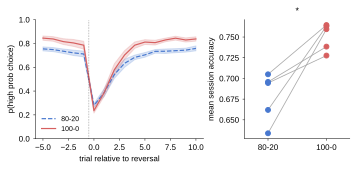

In [5]:
def _per_animal_position_summary(df, block_labels, value_col):
    trans = block_labels.rename(columns={"Session_ID": "session_id", "BlockCount": "to_block", "Animal_Name": "animal"})
    aligned = ra.accuracy_by_position_relative_to_transition(
        df, trans, value_col, cfg["reversal_alignment_pre"], cfg["reversal_alignment_post"], block_col="BlockCount"
    )
    per_animal = aligned.groupby(["position", "animal"])["accuracy"].mean().reset_index()
    summary = per_animal.groupby("position")["accuracy"].agg(
        mean="mean", sem=lambda x: x.std(ddof=1) / np.sqrt(len(x)) if len(x) > 1 else np.nan, n="count"
    ).reset_index()
    return per_animal, summary

pos_animal_acc_80, pos_summary_acc_80 = _per_animal_position_summary(df_80, block_labels_80, "High_Prob")
pos_animal_acc_100, pos_summary_acc_100 = _per_animal_position_summary(df_100, block_labels_100, "High_Prob")

animal_acc_80 = df_80.groupby("Animal_Name")["High_Prob"].mean()
animal_acc_100 = df_100.groupby("Animal_Name")["High_Prob"].mean()
acc_comparison = cross_condition.paired_animal_comparison(
    animal_acc_80.to_dict(), animal_acc_100.to_dict(), OVERLAPPING_ANIMALS
)
print(f"Mean session accuracy, 80-20 vs 100-0 (per-animal paired t-test, n={acc_comparison['n']}): "
      f"t={acc_comparison['t']:.3f}, p={acc_comparison['p']:.4g}")
manifest["panel_a_accuracy_comparison"] = {
    "animals": acc_comparison["animals"], "values_80_20": acc_comparison["values_80_20"].tolist(),
    "values_100_0": acc_comparison["values_100_0"].tolist(), "t": acc_comparison["t"], "p": acc_comparison["p"],
}

from IPython.display import SVG, display

out_a = os.path.join(FIG_DIR, "Fig8a_reversal_aligned_accuracy.svg")
plotting.plot_panel_a(pos_summary_acc_80, pos_summary_acc_100, acc_comparison, out_a)
display(SVG(out_a))

## Panel b
**b,** Mean probability of switching (p(switch)) aligned to block reversal for
80-20 (blue, dashed) and 100-0 (purple, solid) conditions. Shaded regions
indicate +/-SEM.

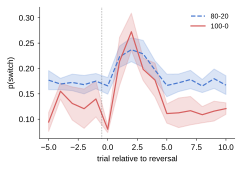

In [6]:
pos_animal_switch_80, pos_summary_switch_80 = _per_animal_position_summary(df_80, block_labels_80, "PhysicalSwitch")
pos_animal_switch_100, pos_summary_switch_100 = _per_animal_position_summary(df_100, block_labels_100, "PhysicalSwitch")

out_b = os.path.join(FIG_DIR, "Fig8b_reversal_aligned_switch.svg")
plotting.plot_panel_b(pos_summary_switch_80, pos_summary_switch_100, out_b)
display(SVG(out_b))

## Panel c
**c,** Proportion of trials spent in each behavioral state (excluding Adapting
trials) for 80-20 and 100-0 conditions. Each panel shows a single state; circles
and squares indicate individual animal means for 80-20 and 100-0 respectively,
connected by lines for paired animals (n=5). **p<0.01, ***p<0.001, paired t-test.

Exploit               : 80-20=0.518  100-0=0.728  t=-14.863  p=0.0001193
Directed Exploration  : 80-20=0.296  100-0=0.111  t=8.185  p=0.001213
Random Exploration    : 80-20=0.057  100-0=0.003  t=16.838  p=7.293e-05
Left Bias             : 80-20=0.065  100-0=0.084  t=-0.658  p=0.5464
Right Bias            : 80-20=0.064  100-0=0.074  t=-0.443  p=0.6806


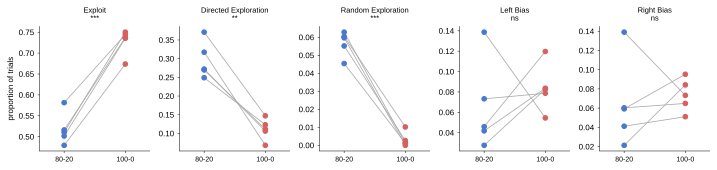

In [7]:
proportions_result = cross_condition.compare_state_proportions(df_80, df_100, cfg["states_full"], OVERLAPPING_ANIMALS)
for state, r in proportions_result.items():
    print(f"{state:22s}: 80-20={np.nanmean(r['values_80_20']):.3f}  100-0={np.nanmean(r['values_100_0']):.3f}  "
          f"t={r['t']:.3f}  p={r['p']:.4g}")
manifest["panel_c_state_proportions"] = {
    state: {"animals": r["animals"], "values_80_20": r["values_80_20"].tolist(),
            "values_100_0": r["values_100_0"].tolist(), "t": r["t"], "p": r["p"]}
    for state, r in proportions_result.items()
}

out_c = os.path.join(FIG_DIR, "Fig8c_state_proportions.svg")
plotting.plot_panel_c(proportions_result, cfg["states_full"], out_c)
display(SVG(out_c))

## Panel d
**d,** Win-stay (left) and lose-switch (right) probabilities for Exploitation
and Directed Exploration states in 80-20 and 100-0 conditions. Bars indicate
group means; circles indicate individual animal means for overlapping animals
(n=5), connected by lines across conditions. *p<0.05, ***p<0.001, paired t-test.

win_stay     Exploit               : 80-20=0.947  100-0=0.940  t=0.770  p=0.4842
win_stay     Directed Exploration  : 80-20=0.769  100-0=0.833  t=-3.991  p=0.01625
lose_switch  Exploit               : 80-20=0.071  100-0=0.385  t=-12.059  p=0.0002712
lose_switch  Directed Exploration  : 80-20=0.377  100-0=0.451  t=-1.309  p=0.2608


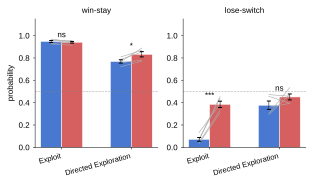

In [8]:
wsls_result = cross_condition.compare_win_stay_lose_switch(df_80, df_100, cfg["wsls_states"], OVERLAPPING_ANIMALS)
for metric in ("win_stay", "lose_switch"):
    for state, r in wsls_result[metric].items():
        print(f"{metric:12s} {state:22s}: 80-20={np.nanmean(r['values_80_20']):.3f}  "
              f"100-0={np.nanmean(r['values_100_0']):.3f}  t={r['t']:.3f}  p={r['p']:.4g}")
manifest["panel_d_win_stay_lose_switch"] = {
    metric: {
        state: {"values_80_20": r["values_80_20"].tolist(), "values_100_0": r["values_100_0"].tolist(),
                "t": r["t"], "p": r["p"]}
        for state, r in wsls_result[metric].items()
    }
    for metric in ("win_stay", "lose_switch")
}

out_d = os.path.join(FIG_DIR, "Fig8d_win_stay_lose_switch.svg")
plotting.plot_panel_d(wsls_result, cfg["wsls_states"], out_d)
display(SVG(out_d))

## Panel e
**e,** Probability of switching as a function of consecutive losses within the
Exploitation state for 80-20 (blue, dashed) and 100-0 (purple, solid) conditions.
Points indicate animal means; error bars indicate +/-SEM.

80-20:
  Loss_Streak     mean      sem  n
           0 0.053818 0.009148  5
           1 0.074632 0.018331  5
           2 0.040691 0.008761  5
           3 0.066667 0.066667  5
           4 0.000000      NaN  1

100-0:
  Loss_Streak     mean      sem  n
           0 0.060172 0.007915  5
           1 0.387069 0.028619  5
           2 0.000000 0.000000  2


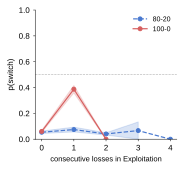

In [9]:
streak_animal_80, streak_summary_80 = cross_condition.switch_vs_consecutive_losses(df_80, "Exploit", cfg["max_consecutive_losses"])
streak_animal_100, streak_summary_100 = cross_condition.switch_vs_consecutive_losses(df_100, "Exploit", cfg["max_consecutive_losses"])
print("80-20:\n", streak_summary_80.to_string(index=False))
print("\n100-0:\n", streak_summary_100.to_string(index=False))
manifest["panel_e_switch_vs_streak"] = {
    "80_20": streak_summary_80.to_dict(orient="records"),
    "100_0": streak_summary_100.to_dict(orient="records"),
}

out_e = os.path.join(FIG_DIR, "Fig8e_switch_vs_consecutive_losses.svg")
plotting.plot_panel_e(streak_summary_80, streak_summary_100, out_e)
display(SVG(out_e))

## Panel f
**f,** Change in trial-to-trial state transition probability between
deterministic and probabilistic reward contingencies (100-0 minus 80-20),
restricted to transitions between Exploitation and Directed Exploration states.
Asterisks indicate significant differences between conditions (paired t-test,
*p<0.05, n=5 animals).

Transition-probability table: 230 (condition, animal, from_state, to_state) rows

Exploitation <-> Directed Exploration difference matrix (100-0 minus 80-20):
  Exploit -> Exploit: diff=+0.070  p=0.0002104
  Exploit -> Directed Exploration: diff=-0.043  p=0.00968
  Directed Exploration -> Exploit: diff=+0.174  p=0.0003984
  Directed Exploration -> Directed Exploration: diff=-0.223  p=0.0003788


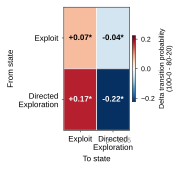

In [10]:
trans_df = cross_condition.compute_transition_probabilities(
    df_80, df_100, cfg["states_full"], OVERLAPPING_ANIMALS, cfg["min_trials_per_transition"]
)
print(f"Transition-probability table: {len(trans_df)} (condition, animal, from_state, to_state) rows")

diff_full = cross_condition.compute_diff_matrix(trans_df, cfg["states_full"], OVERLAPPING_ANIMALS)
diff_main = cross_condition.compute_diff_matrix(trans_df, cfg["states_key_main"], OVERLAPPING_ANIMALS)

print("\nExploitation <-> Directed Exploration difference matrix (100-0 minus 80-20):")
for i, fs in enumerate(diff_main["states"]):
    for j, ts in enumerate(diff_main["states"]):
        print(f"  {fs} -> {ts}: diff={diff_main['diff_matrix'][i, j]:+.3f}  p={diff_main['pval_matrix'][i, j]:.4g}")

manifest["panel_f_full_5state_diff_matrix"] = {
    "states": diff_full["states"], "diff_matrix": diff_full["diff_matrix"].tolist(),
    "pval_matrix": diff_full["pval_matrix"].tolist(),
}
manifest["panel_f_exploit_directed_diff_matrix"] = {
    "states": diff_main["states"], "diff_matrix": diff_main["diff_matrix"].tolist(),
    "pval_matrix": diff_main["pval_matrix"].tolist(),
}

out_f = os.path.join(FIG_DIR, "Fig8f_transition_probability_change.svg")
plotting.plot_panel_f(diff_main, out_f)
display(SVG(out_f))

## Sticky Q-learning model fit -- 80-20 vs. 100-0 (parallel sanity check)
Reuses `q_following_model.fit_sticky_qlearning`/`compute_qvalues_sticky` unchanged
(same model form/bounds as Supp Fig 3). Not part of any of panels a-f's own
dependency chain (state classification doesn't use Q-values) -- included as a
parallel cross-condition comparison, mirroring the earlier build's own STEP 6/7.

In [11]:
sticky_x0 = config["suppfig3"]["sticky_model_x0"]
sticky_bounds = config["suppfig3"]["sticky_model_bounds"]
sticky_result = cross_condition.fit_sticky_and_compare(
    df_80, df_100, sticky_x0, sticky_bounds, q_following_model.fit_sticky_qlearning
)
print("Sticky Q-learning params, 80-20 vs 100-0 (paired t-test across shared animals):")
for param, stats in sticky_result["comparison"].items():
    print(f"  {param}: 80-20={stats['mean_80_20']:.3f}+/-{stats['sem_80_20']:.3f}  "
          f"100-0={stats['mean_100_0']:.3f}+/-{stats['sem_100_0']:.3f}  t={stats['t']:.3f}  p={stats['p']:.4g}")
manifest["sticky_qlearning_comparison"] = sticky_result["comparison"]

Sticky Q-learning params, 80-20 vs 100-0 (paired t-test across shared animals):
  alpha: 80-20=0.740+/-0.052  100-0=0.937+/-0.042  t=-2.645  p=0.05726
  beta: 80-20=1.120+/-0.139  100-0=0.929+/-0.059  t=1.239  p=0.283
  kappa: 80-20=1.261+/-0.128  100-0=1.514+/-0.135  t=-1.436  p=0.2243


## Values manifest

In [12]:
manifest_path = os.path.join(MANIFEST_DIR, "Fig8.json")
with open(manifest_path, "w") as f:
    json.dump(manifest, f, indent=2, default=str)
print(f"\nSaved values manifest: {manifest_path}")


Saved values manifest: ../outputs/values_manifests/Fig8.json
